<a href="https://colab.research.google.com/github/Somrat390/Pytorch/blob/main/Neural_Network_with_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Workflow

In [1]:
import torch
from torch import nn ## nn is the building block of neural network
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

# Data(Preparing and loading)

In [2]:
# Create *known* parameter

weight = 0.7
bias = 0.3

#create data
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)

y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

# Splitting data into training and testing dataset

In [3]:
train_split = int(0.8 * len(X))
X_train,y_train=X[:train_split] , y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [4]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [5]:
def plot_prediction(train_data = X_train,train_labels= y_train,test_data=X_test,test_labels=y_test,prediction=None):
  plt.figure(figsize=(10,7))

  plt.scatter(train_data,train_labels, c="b", s=4, label="Trainig data")

  plt.scatter(test_data,test_labels,c="g", s=4, label="Testing data")


  if prediction is not None:

    plt.scatter(test_data,prediction,c="r",s=4,label="Predictions")

  plt.legend(prop={"size": 14})

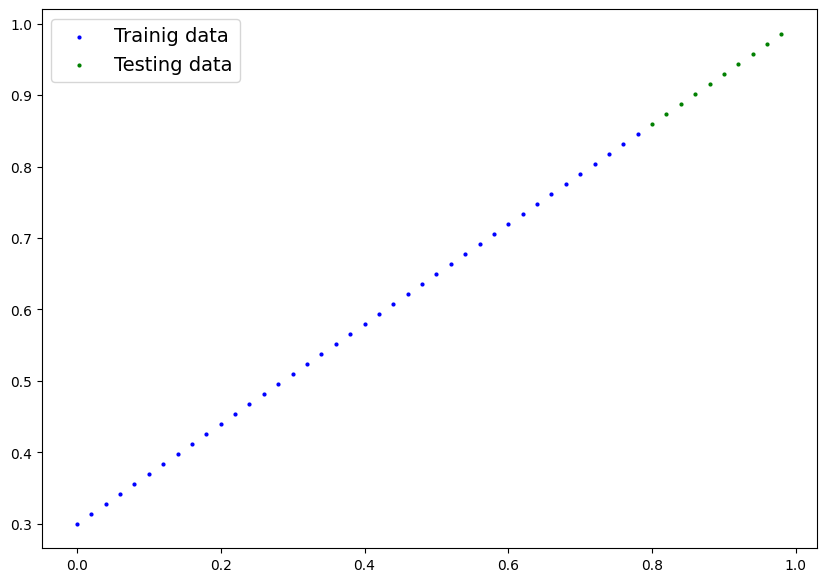

In [6]:
plot_prediction()

# Model building

In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(
        1,requires_grad=True,dtype=torch.float
    ))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x:torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias



In [64]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [65]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
weight, bias

(0.7, 0.3)

In [11]:
# Making prediction
with torch.inference_mode():
  y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [12]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

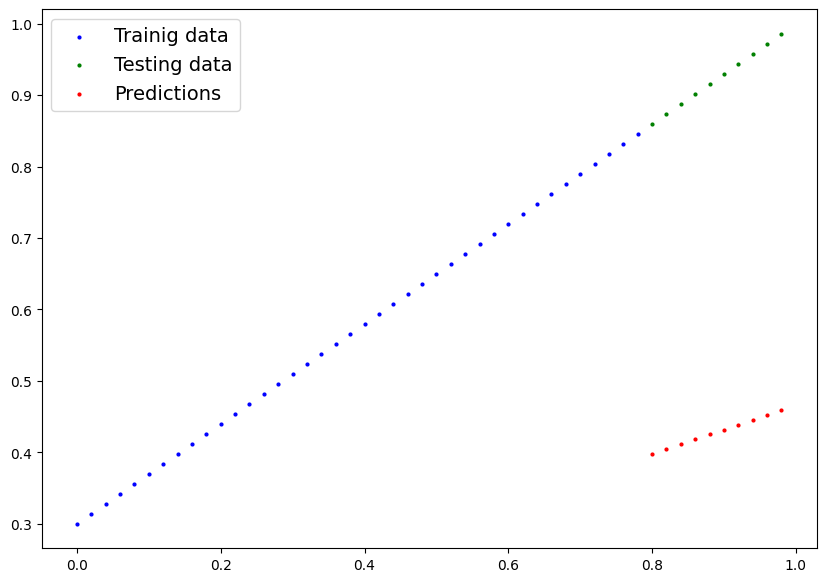

In [13]:
plot_prediction(prediction=y_pred)

In [66]:
# Setup a loss funtion
loss_fn = nn.L1Loss()

#setting optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

# Training loop
- Loop through data
- Forward Pass
- calculate loss
- oprimizer zero grad
- Backpropagation
- improve loss

In [70]:

torch.manual_seed(42)
# Training loop
epochs = 100

for epoch in range(epochs):
  model_0.train() # train mode in pytorch sets all parameter that require gradients

  y_pred = model_0(X_train) #forward pass

  loss = loss_fn(y_pred, y_train) # calculate loss
  print(f"Loss {loss}")
  optimizer.zero_grad() #optimizer to zero grad

  loss.backward() # backpropagation

  optimizer.step() #performing gradient descent

  model_0.eval() # turn off gradient tracking
  with torch.inference_mode():
      y_pred = model_0(X_test)

      test_loss = loss_fn(y_pred, y_test)

  if epoch%10 == 0:
       print(f"Epoc: {epoch} | Loss{loss} | Test loss{test_loss}")
       print(model_0.state_dict())


Loss 0.024458957836031914
Epoc: 0 | Loss0.024458957836031914 | Test loss0.05646304413676262
OrderedDict({'weights': tensor([0.5800]), 'bias': tensor([0.3503])})
Loss 0.024110013619065285
Loss 0.02376994863152504
Loss 0.02342480979859829
Loss 0.023080935701727867
Loss 0.022739607840776443
Loss 0.022391926497220993
Loss 0.022054409608244896
Loss 0.02170540764927864
Loss 0.021366719156503677
Loss 0.021020207554101944
Epoc: 10 | Loss0.021020207554101944 | Test loss0.04819049686193466
OrderedDict({'weights': tensor([0.5972]), 'bias': tensor([0.3433])})
Loss 0.020677709951996803
Loss 0.02033500373363495
Loss 0.01998869702219963
Loss 0.019649803638458252
Loss 0.019300809130072594
Loss 0.018963487818837166
Loss 0.01861560344696045
Loss 0.018274478614330292
Loss 0.017930403351783752
Loss 0.01758546568453312
Epoc: 20 | Loss0.01758546568453312 | Test loss0.04060482233762741
OrderedDict({'weights': tensor([0.6141]), 'bias': tensor([0.3358])})
Loss 0.017245199531316757
Loss 0.016896454617381096
Los

In [73]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [74]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [21]:
weight, bias

(0.7, 0.3)

In [71]:
with torch.inference_mode():
  y_pred = model_0(X_test)

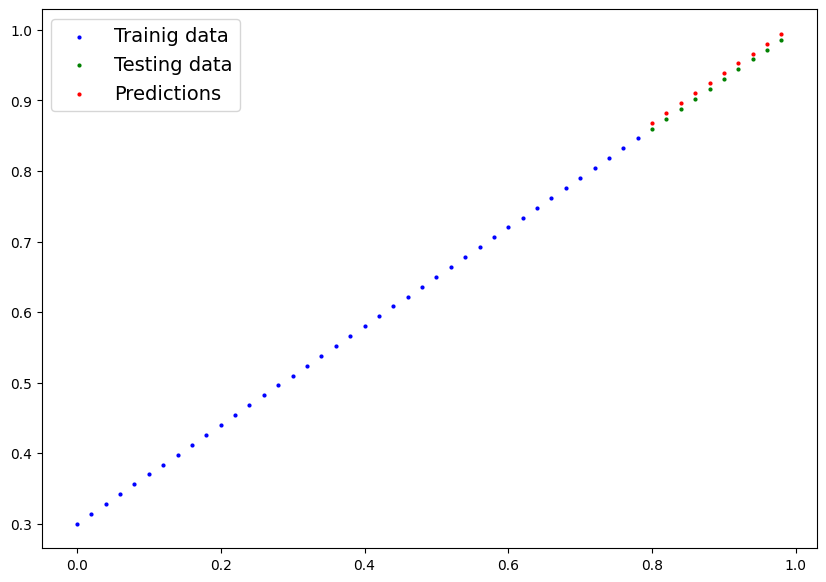

In [72]:
plot_prediction(prediction=y_pred)